In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
daily_returns = pd.read_csv(
    "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

In [4]:
daily_returns.head()

,ASIANPAINT.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDALCO.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,NTPC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,
2015-01-02,0.034573,0.005925,0.013917,0.010413,-0.003296,0.028385,0.019651,0.003132,0.010289,0.021092,-0.010024,0.005642,0.013689,0.012035,-0.002646,0.003981,0.004926,0.015577,0.013317,0.029897
2015-01-05,-0.000065,-0.022189,-0.008443,-0.020300,0.005754,0.002070,-0.008593,0.003937,-0.004011,0.013912,-0.005063,0.026253,-0.002770,0.001081,-0.010954,-0.007930,0.000605,0.014486,-0.015197,0.002042
2015-01-06,-0.023871,-0.007844,-0.015567,-0.021996,0.018940,-0.042419,-0.020893,-0.025693,-0.011923,-0.033355,-0.005581,-0.015241,-0.033333,-0.022318,-0.045384,-0.041087,-0.022014,-0.048476,-0.036866,-0.028060
2015-01-07,0.020092,0.002400,0.002919,-0.029335,0.035110,-0.027039,0.004785,-0.018598,0.016103,-0.002394,0.010317,0.012518,0.024066,0.014359,0.021768,0.000834,0.001546,-0.019168,-0.011812,-0.003950
2015-01-08,0.063043,0.017324,0.021005,0.024513,0.018893,0.027199,0.005042,0.025032,0.054385,0.006365,0.010987,0.010981,0.016836,0.004356,-0.014339,0.015659,0.011114,0.015557,0.010795,0.025337


In [5]:
train_returns = daily_returns.loc[
    "2015-01-01":"2022-12-31"
].copy()

In [6]:
test_returns = daily_returns.loc[
    "2023-01-01":"2025-12-31"
].copy()

In [7]:
print("Training period:")
print(train_returns.index.min(), "to", train_returns.index.max())

print("\nTesting period:")
print(test_returns.index.min(), "to", test_returns.index.max())

Training period:
2015-01-02 00:00:00 to 2022-12-30 00:00:00

Testing period:
2023-01-02 00:00:00 to 2025-12-31 00:00:00


In [8]:
train_mean_daily = train_returns.mean()

train_expected_returns = (
    (1 + train_mean_daily) ** 252 - 1
)

In [9]:
train_covariance = (
    train_returns.cov() * 252
)

In [10]:
print(train_expected_returns)

ASIANPAINT.NS    0.250149
BHARTIARTL.NS    0.186697
HDFCBANK.NS      0.210404
HINDALCO.NS      0.262696
HINDUNILVR.NS    0.219871
ICICIBANK.NS     0.216621
INFY.NS          0.229266
ITC.NS           0.112487
KOTAKBANK.NS     0.190951
LT.NS            0.161227
M&M.NS           0.158528
MARUTI.NS        0.184855
NTPC.NS          0.122346
POWERGRID.NS     0.181285
RELIANCE.NS      0.315230
SBIN.NS          0.168567
SUNPHARMA.NS     0.085056
TATASTEEL.NS     0.270910
TCS.NS           0.183233
ULTRACEMCO.NS    0.180862
dtype: float64


In [11]:
train_covariance.shape

(20, 20)

In [12]:
def portfolio_statistics(
    weights,
    expected_returns,
    cov_matrix,
    risk_free_rate=0.06
):
    
    portfolio_return = np.dot(
        weights,
        expected_returns
    )
    
    portfolio_variance = (
        weights.T @ cov_matrix @ weights
    )
    
    portfolio_volatility = np.sqrt(
        portfolio_variance
    )
    
    sharpe_ratio = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return (
        portfolio_return,
        portfolio_volatility,
        sharpe_ratio
    )

In [13]:
from scipy.optimize import minimize

In [14]:
n_assets = len(train_expected_returns)

In [15]:
constraints = [
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }
]

In [16]:
bounds = [
    (0, 0.25)
    for _ in range(n_assets)
]

#### Minimum Variance Portfolio

In [17]:
def portfolio_variance(weights):
    return (
        weights.T
        @ train_covariance.values
        @ weights
    )

In [18]:
initial_weights = np.ones(n_assets) / n_assets

In [19]:
min_var_result = minimize(
    portfolio_variance,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [20]:
print(min_var_result.success)

True


#### minimum-variance weights

In [21]:
min_var_weights = min_var_result.x

In [22]:
print(min_var_weights)
print("Weight sum:", min_var_weights.sum())

[7.77181516e-02 4.11186148e-02 1.08022874e-01 2.53714155e-18
 1.68610407e-01 0.00000000e+00 5.56225065e-02 9.87189776e-02
 2.77889880e-18 3.20393433e-18 0.00000000e+00 1.38934231e-18
 6.60050114e-02 1.56821132e-01 6.10373804e-03 0.00000000e+00
 7.25009098e-02 2.32953918e-18 1.48757677e-01 7.69449546e-18]
Weight sum: 1.0


#### Maximum Sharpe Portfolio

In [23]:
risk_free_rate = 0.06

def negative_sharpe(weights):
    
    portfolio_return = np.dot(
        weights,
        train_expected_returns.values
    )
    
    portfolio_variance = (
        weights.T
        @ train_covariance.values
        @ weights
    )
    
    portfolio_volatility = np.sqrt(
        portfolio_variance
    )
    
    sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility
    
    return -sharpe

In [24]:
max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

In [25]:
print(max_sharpe_result.success)

True


#### Maximum Sharpe weights

In [26]:
max_sharpe_weights = max_sharpe_result.x

In [27]:
print(max_sharpe_weights)
print("Weight sum:", max_sharpe_weights.sum())

[1.69529573e-01 0.00000000e+00 7.37244791e-02 0.00000000e+00
 1.87939098e-01 0.00000000e+00 1.56927492e-01 6.42934786e-17
 1.11956285e-16 5.90888910e-17 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.21900383e-01 2.50000000e-01 0.00000000e+00
 0.00000000e+00 3.24182839e-02 7.56069082e-03 9.17689966e-17]
Weight sum: 1.0000000000000007


In [28]:
weights_table = pd.DataFrame({
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights
}, index=train_returns.columns)

In [29]:
weights_table

,Minimum Variance,Maximum Sharpe
ASIANPAINT.NS,7.771815e-02,1.695296e-01
BHARTIARTL.NS,4.111861e-02,0.000000e+00
HDFCBANK.NS,1.080229e-01,7.372448e-02
HINDALCO.NS,2.537142e-18,0.000000e+00
HINDUNILVR.NS,1.686104e-01,1.879391e-01
ICICIBANK.NS,0.000000e+00,0.000000e+00
INFY.NS,5.562251e-02,1.569275e-01
ITC.NS,9.871898e-02,6.429348e-17
KOTAKBANK.NS,2.778899e-18,1.119563e-16
LT.NS,3.203934e-18,5.908889e-17


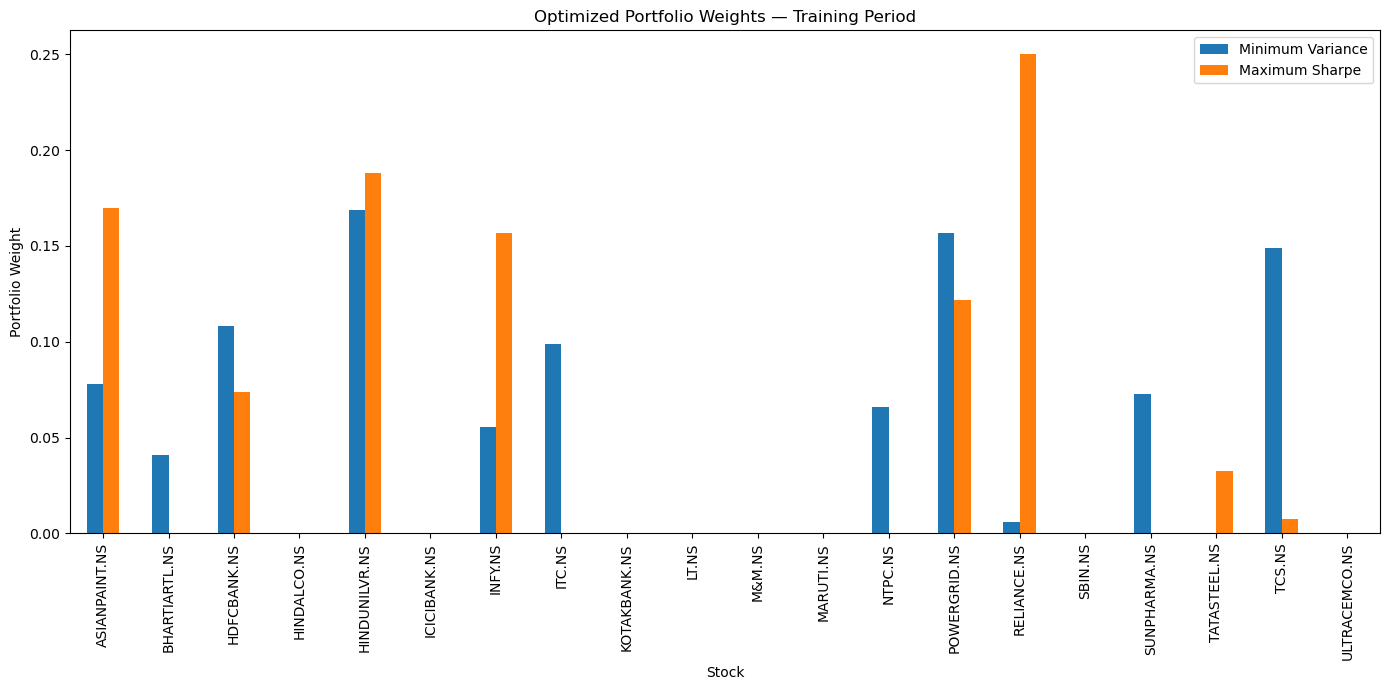

In [30]:
weights_table.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Optimized Portfolio Weights — Training Period"
)

plt.ylabel("Portfolio Weight")
plt.xlabel("Stock")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## test-period portfolio returns

In [31]:
test_min_var_returns = (
    test_returns
    @ min_var_weights
)

In [32]:
test_max_sharpe_returns = (
    test_returns
    @ max_sharpe_weights
)

In [33]:
equal_weights = np.ones(n_assets) / n_assets

test_equal_weight_returns = (
    test_returns
    @ equal_weights
)

### Nifty 50 benchmark

In [34]:
import yfinance as yf

nifty = yf.download(
    "^NSEI",
    start="2023-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


In [35]:
nifty_prices = nifty["Close"].squeeze()

In [36]:
nifty_returns = nifty_prices.pct_change().dropna()

In [37]:
print(type(nifty_prices))
print(type(nifty_returns))
print(nifty_returns.shape)

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
(739,)


In [38]:
wealth_min_var = (
    1 + test_min_var_returns
).cumprod()

wealth_max_sharpe = (
    1 + test_max_sharpe_returns
).cumprod()

wealth_equal_weight = (
    1 + test_equal_weight_returns
).cumprod()

wealth_nifty = (
    1 + nifty_returns
).cumprod()

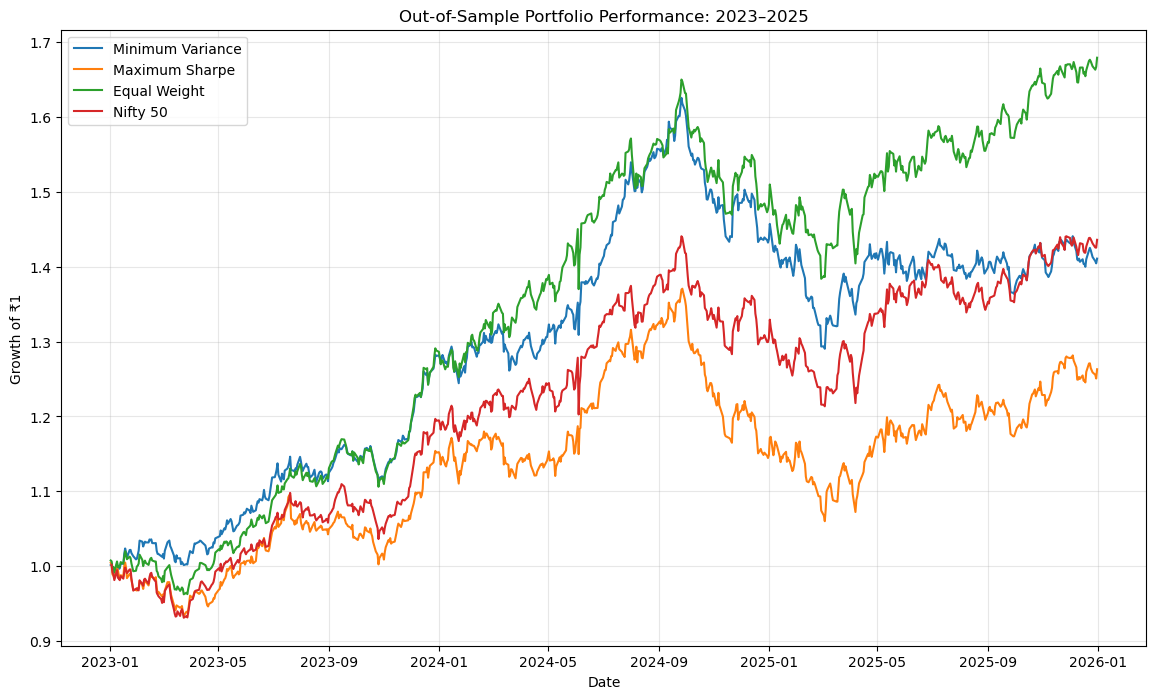

In [39]:
plt.figure(figsize=(14, 8))

plt.plot(
    wealth_min_var,
    label="Minimum Variance"
)

plt.plot(
    wealth_max_sharpe,
    label="Maximum Sharpe"
)

plt.plot(
    wealth_equal_weight,
    label="Equal Weight"
)

plt.plot(
    wealth_nifty,
    label="Nifty 50"
)

plt.title(
    "Out-of-Sample Portfolio Performance: 2023–2025"
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹1")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### test-period performance

In [40]:
def performance_metrics(returns, risk_free_rate=0.06):
    
    # Make sure returns are a clean numeric Series
    returns = pd.Series(returns).dropna().astype(float)
    
    # Annualized return using compounded daily returns
    annual_return = (
        (1 + returns).prod()
        ** (252 / len(returns))
        - 1
    )
    
    # Annualized volatility
    annual_volatility = (
        returns.std() * np.sqrt(252)
    )
    
    # Sharpe ratio
    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility
    
    # Cumulative wealth
    cumulative = (
        1 + returns
    ).cumprod()
    
    # Running maximum
    running_max = cumulative.cummax()
    
    # Drawdown
    drawdown = (
        cumulative / running_max
    ) - 1
    
    # Maximum drawdown
    max_drawdown = drawdown.min()
    
    return {
        "Annual Return": float(annual_return),
        "Annual Volatility": float(annual_volatility),
        "Sharpe Ratio": float(sharpe),
        "Maximum Drawdown": float(max_drawdown)
    }

In [41]:
results = {
    "Minimum Variance": performance_metrics(
        test_min_var_returns
    ),
    
    "Maximum Sharpe": performance_metrics(
        test_max_sharpe_returns
    ),
    
    "Equal Weight": performance_metrics(
        test_equal_weight_returns
    ),
    
    "Nifty 50": performance_metrics(
        nifty_returns
    )
}

In [42]:
performance_table = pd.DataFrame(results).T

In [43]:
performance_table

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,0.124331,0.111355,0.577712,-0.206221
Maximum Sharpe,0.082764,0.124806,0.182397,-0.226535
Equal Weight,0.193013,0.119530,1.112801,-0.161291
Nifty 50,0.131303,0.120165,0.593373,-0.157667


In [44]:
performance_table.dtypes

Annual Return        float64
Annual Volatility    float64
Sharpe Ratio         float64
Maximum Drawdown     float64
dtype: object

In [45]:
performance_table_display = performance_table.copy()

for col in [
    "Annual Return",
    "Annual Volatility",
    "Maximum Drawdown"
]:
    performance_table_display[col] = (
        performance_table_display[col] * 100
    ).round(2)

performance_table_display["Sharpe Ratio"] = (
    performance_table_display["Sharpe Ratio"]
    .round(2)
)

performance_table_display

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Minimum Variance,12.43,11.14,0.58,-20.62
Maximum Sharpe,8.28,12.48,0.18,-22.65
Equal Weight,19.30,11.95,1.11,-16.13
Nifty 50,13.13,12.02,0.59,-15.77


In [46]:
print(
    test_min_var_returns.index.min(),
    test_min_var_returns.index.max()
)

print(
    nifty_returns.index.min(),
    nifty_returns.index.max()
)

2023-01-02 00:00:00 2025-12-31 00:00:00
2023-01-03 00:00:00 2025-12-31 00:00:00


In [47]:
print(
    len(test_min_var_returns),
    len(nifty_returns)
)

740 739


In [48]:
performance_table.to_csv(
    "performance_table.csv"
)

print("Performance table saved successfully.")

Performance table saved successfully.
